Helper functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pandas as pd
import torch
from scipy.integrate import solve_ivp
from collections.abc import Callable
from typing import Tuple, Optional
from scipy.integrate import odeint

# Helper: wrap a PyTorch model that takes a torch tensor of shape (N,) or (N,1)
def make_torch_wrapper(pt_model, device="cpu", batch_dim=False):
    """
    Wrap a PyTorch model so it can be called as a numpy function u -> out (numpy array).
    - pt_model should accept a torch tensor of shape (N,) or (N,1) and return (N,) or (N,1)
    - device: 'cpu' or 'cuda'
    - batch_dim: if True, the model expects input shape (batch, N) or similar; keep False for elementwise
    Returns: callable(u_numpy) -> numpy array
    """
    pt_model.to(device)
    pt_model.eval()
    def wrapper(u_np: np.ndarray) -> np.ndarray:
        # Convert to torch tensor
        with torch.no_grad():
            u_t = torch.from_numpy(u_np.astype(np.float32)).to(device)
            # If model expects shape (N,1), reshape
            if u_t.ndim == 1:
                u_t_in = u_t.unsqueeze(1)  # (N,1)
            else:
                u_t_in = u_t
            out = pt_model(u_t_in)
            # If out has shape (N,1) or (N,), convert to 1D numpy
            out_np = out.detach().cpu().numpy()
            out_np = out_np.reshape(u_np.shape)
        return out_np
    return wrapper

# Solve Burger's equation to get the solution at training points
# (PDE ---(FFT)---> ODE system)
def burg_system(u, t, k, mu, nu):
    # Spatial derivative in the Fourier domain
    u_hat = np.fft.fft(u)
    u_hat_x = 1j * k * u_hat
    u_hat_xx = -k**2 * u_hat

    # Switching in the spatial domain
    u_x = np.fft.ifft(u_hat_x)
    u_xx = np.fft.ifft(u_hat_xx)

    # ODE resolution
    u_t = -mu * u * u_x + nu * u_xx
    return u_t.real

# reconstruct the solution using the learned NN 'D_model' and 'V_model' at the training points (x_train, t_train)
def recon_plot(x_train, t_train, D_model, V_model, u_NN_IC):
    D_callable = make_torch_wrapper(D_model, device='cpu')
    V_callable = make_torch_wrapper(V_model, device='cpu')
    u_sim = simulate_pde(x_train, u_NN_IC, D_callable, V_callable,
                       t_span=(t_train[0], t_train[-1]),
                       t_eval=t_train,
                       integrator="RK45")
    return u_sim

def simulate_pde(x: np.ndarray,
                 IC: np.ndarray,
                 D_callable: Callable[[np.ndarray], np.ndarray],
                 V_callable: Callable[[np.ndarray], np.ndarray],
                 t_span: Tuple[float, float] = (0.0, 20.0),
                 t_eval: Optional[np.ndarray] = None,
                 integrator: str = "RK45",
                 rtol: float = 1e-6,
                 atol: float = 1e-8,
                 save_path: Optional[str] = None,
                 upwind: bool = True,
                 D_average: str = "arithmetic",
                 return_full_sol: bool = False):
    """
    Simulate u_t = ( D(u) * u_x - u * V(u) )_x  on a 1D grid with zero-flux (Neumann) boundaries.

    Parameters
    ----------
    x : np.ndarray
        1D grid (monotonic). Can be non-uniform.
    IC : np.ndarray
        Initial condition (same length as x).
    D_callable : Callable[[np.ndarray], np.ndarray]
        Function mapping u_array -> D_array (same length as u).
    V_callable : Callable[[np.ndarray], np.ndarray]
        Function mapping u_array -> V_array (same length as u).
    t_span : tuple(float, float)
        (t0, tf)
    t_eval : np.ndarray or None
        Times to evaluate solution. If None, uses 201 points between t0 and tf.
    integrator : str
        ODE solver name for solve_ivp (e.g. "RK45", "BDF" for stiff problems).
    rtol, atol : float
        Solver tolerances.
    save_path : str or None
        If provided, saves final state (u at last t_eval) to this .npy path.
    upwind : bool
        If True, use first-order upwind for advective flux (stable for advection).
        If False, use central (averaged) flux for advection (less dissipative but can oscillate).
    D_average : {"arithmetic", "harmonic"}
        How to compute D at interfaces from node values. Harmonic can be better for
        strongly varying diffusivity.
    return_full_sol : bool
        If True, return (sol, sol.y.T) where sol.y.T is shape (len(t_eval), N).
        Otherwise return sol only.

    Returns
    -------
    sol : OdeResult
        The object returned by scipy.integrate.solve_ivp.
        (Optionally also the transposed solution array if return_full_sol=True)
    """

    x = np.asarray(x)
    if x.ndim != 1:
        raise ValueError("x must be a 1D array of grid points.")
    N = x.size

    IC = np.asarray(IC)
    if IC.shape != x.shape:
        raise ValueError("IC must have same shape as x.")

    # mesh spacing (supports non-uniform)
    dxs = np.diff(x)  # length N-1
    if np.any(dxs <= 0):
        raise ValueError("x must be strictly increasing.")

    if t_eval is None:
        t_eval = np.linspace(t_span[0], t_span[1], 201)

    def interface_average(Dn: np.ndarray) -> np.ndarray:
        # Dn length N -> returns D_half length N-1 on interfaces i+1/2
        if D_average == "arithmetic":
            return 0.5 * (Dn[:-1] + Dn[1:])
        elif D_average == "harmonic":
            # avoid divide-by-zero: add a tiny epsilon if necessary
            eps = 1e-12
            return 2.0 * (Dn[:-1] * Dn[1:]) / (Dn[:-1] + Dn[1:] + eps)
        else:
            raise ValueError("D_average must be 'arithmetic' or 'harmonic'")

    def rhs(t, u_vec):
        u = np.asarray(u_vec)
        if u.shape[0] != N:
            raise ValueError("u_vec must have length N")

        # Evaluate D and V at physical nodes
        Dn = D_callable(u)
        Vn = V_callable(u)
        if Dn.shape != u.shape:
            raise ValueError("D_callable must return array of same shape as u")
        if Vn.shape != u.shape:
            raise ValueError("V_callable must return array of same shape as u")

        # ------------------------------------------------------------
        # Ghost-node extension imposing Neumann BC: u_x = 0
        # Using mirrored ghost nodes:
        #   u_{-1} = u_1,   u_N = u_{N-2}
        # so that centered boundary derivative is zero.
        # ------------------------------------------------------------
        u_ext = np.empty(N + 2, dtype=u.dtype)
        u_ext[1:-1] = u
        u_ext[0] = u[1]
        u_ext[-1] = u[-2]

        # Extend D and V consistently to ghost nodes
        D_ext = np.empty(N + 2, dtype=Dn.dtype)
        V_ext = np.empty(N + 2, dtype=Vn.dtype)
        D_ext[1:-1] = Dn
        V_ext[1:-1] = Vn
        D_ext[0] = Dn[1]
        D_ext[-1] = Dn[-2]
        V_ext[0] = Vn[1]
        V_ext[-1] = Vn[-2]

        # Extended interface spacings, length N+1
        # interfaces are:
        #   x_{-1/2}, x_{1/2}, ..., x_{N-3/2}, x_{N-1/2}
        dx_ext = np.empty(N + 1, dtype=float)
        dx_ext[1:-1] = dxs
        dx_ext[0] = dxs[0]
        dx_ext[-1] = dxs[-1]

        # Interface values for D and V, length N+1
        D_half = 0.5 * (D_ext[:-1] + D_ext[1:])
        V_half = 0.5 * (V_ext[:-1] + V_ext[1:])

        # Diffusive flux at all interfaces
        diff_flux = D_half * (u_ext[1:] - u_ext[:-1]) / dx_ext

        # Advective flux at all interfaces
        if upwind:
            u_left = u_ext[:-1]
            u_right = u_ext[1:]
            u_hat = np.where(V_half >= 0, u_left, u_right)
            adv_flux = V_half * u_hat
        else:
            u_avg = 0.5 * (u_ext[:-1] + u_ext[1:])
            adv_flux = V_half * u_avg

        # Total flux at all interfaces:
        # F = D(u) u_x - u V(u)
        flux = diff_flux - adv_flux   # length N+1

        # Conservative divergence at physical nodes
        dx_node = np.empty(N, dtype=float)
        if N == 1:
            dx_node[0] = 1.0
        else:
            dx_node[0] = dxs[0]
            dx_node[-1] = dxs[-1]
            if N > 2:
                dx_node[1:-1] = 0.5 * (dxs[:-1] + dxs[1:])

        dudt = (flux[1:] - flux[:-1]) / dx_node
        return dudt

    sol = solve_ivp(rhs, t_span, IC, method=integrator, t_eval=t_eval, rtol=rtol, atol=atol)

    return sol.y.T


Plot formatting & setups

In [2]:
# plot formatting
plt.rcParams['font.family'] = 'overall_overall_times New Roman'
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.labelweight'] = 'bold'  # Bold axis labels
plt.rcParams['axes.titleweight'] = 'bold'  # Bold title
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = str(20)
plt.rcParams['lines.linewidth'] = 2
alpha_val = 0.4

# epochs for training history
epoch_hist = np.arange(0, 4001, 1)

# time resolution
Nt, t_end, t_min = 7, 10.0, 0.0
t_train = np.linspace(t_min, t_end, Nt)

# spatial resolutions
L = 7.0
x_min, x_max = -L, L
dx_long = 0.04
x_train_long = np.arange(x_min, x_max+dx_long, dx_long)
Nx_long = len(x_train_long)
# subsampled the spatial grid for training the BINN
x_train = x_train_long[::5]
dx = x_train[1] - x_train[0]
Nx = len(x_train)

mu = 0.6 # coefficient for the advection term
nu = 0.01 # diffusion coefficient

# solution 
k = 2 * np.pi * np.fft.fftfreq(Nx_long, d=dx_long) # Wave number discretization
u0 = np.exp(-(x_train_long) ** 2 / 2) # Initial condition
u_true_long = odeint(burg_system, u0, t_train, args=(k, mu, nu,), mxstep=5000)
# subsampled true solution at training points
u_true = u_true_long[:, ::5]
u_min_np, u_max_np = u_true.min(), u_true.max()
U_grid= np.linspace(u_min_np, u_max_np, Nx)

D_true = nu * np.ones(np.shape(U_grid))
V_true = (mu / 2) * U_grid

# the variances we used 
variances = [0.0, 0.01, 0.001]
seed = 2

NumRep = 10

top_load_folder = '../ARCresults_subsampled/Burgers_subsample/'
top_save_folder = '../Figures_subsampled/Fig4_subsampled/'

subfolders = ['Const_lr_var0.0/', 'Const_lr_var0.01/', 'Const_lr_var0.001/']

learning_rates = [5e-1, 5e-2, 5e-3, 5e-4, 5e-5, 5e-6, 5e-7]
learning_rates1 = [5e-2, 5e-3, 5e-4, 5e-5, 5e-7]

colors1 = sns.color_palette("Set2", len(learning_rates1))
colors = sns.color_palette("Set1", 2)
alpha_val = 0.4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Plot: total validation over epochs

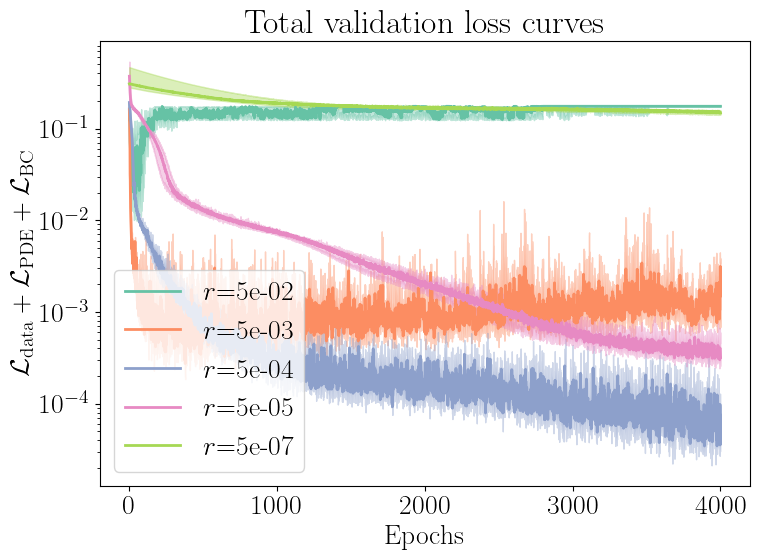

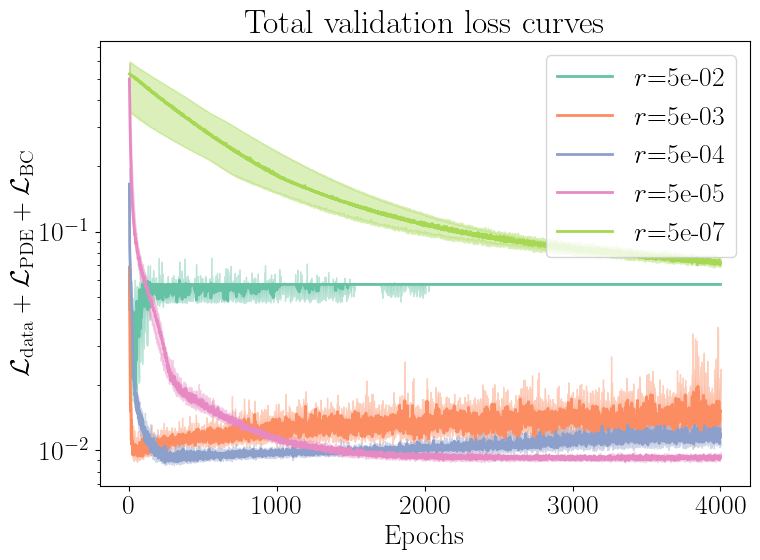

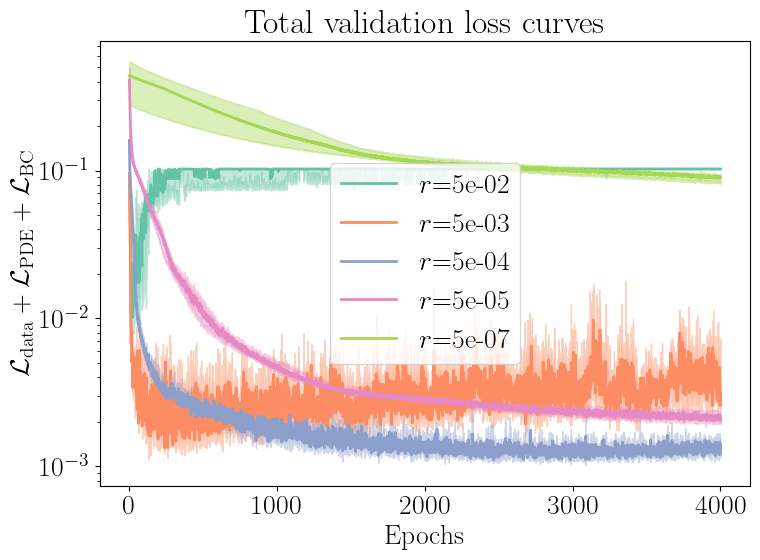

In [3]:
for var, subfolder in zip(variances, subfolders):

    load_dir = top_load_folder + subfolder
    save_dir = top_save_folder + f'var{var}/'

    fig1, ax1 = plt.subplots(figsize=(8, 6))

    for lr_ind, lr in enumerate(learning_rates1):
        val_pdeloss_S = np.load(load_dir + f'{lr}/val_pdeloss_S.npy', allow_pickle=True)
        val_uloss_S = np.load(load_dir + f'{lr}/val_uloss_S.npy', allow_pickle=True)
        val_BCloss_S = np.load(load_dir + f'{lr}/val_BCloss_S.npy', allow_pickle=True)
        val_pdeloss_S, val_uloss_S, val_BCloss_S = np.asarray(val_pdeloss_S, dtype=float), np.asarray(val_uloss_S, dtype=float), np.asarray(val_BCloss_S, dtype=float)
        total_loss = val_uloss_S + val_BCloss_S + val_pdeloss_S

        median_total_loss = np.median(total_loss, axis=0)
        q1_total_loss = np.percentile(total_loss, 25, axis=0)
        q3_total_loss = np.percentile(total_loss, 75, axis=0)

        ax1.plot(epoch_hist, median_total_loss, label=rf'$r$={lr:.0e}', color=colors1[lr_ind])
        ax1.fill_between(epoch_hist, q1_total_loss, q3_total_loss, color=colors1[lr_ind], alpha=alpha_val)

    ax1.set_yscale('log')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel(r'$\mathcal{L}_{\mathrm{data}} + \mathcal{L}_{\mathrm{PDE}} + \mathcal{L}_{\mathrm{BC}}$')
    ax1.set_title(f'Total validation loss curves')
    ax1.legend(loc='best')
    fig1.tight_layout()
    
    fig1.savefig(save_dir + f'total_valLoss_var{var}.svg', format='svg', bbox_inches='tight')


Loop through variances to store u_reconstr, and L2RE of u_NN and u_reconstr

In [4]:
for var, subfolder in zip(variances, subfolders):

    noise_level = np.sqrt(var)
    print(f"Processing noise level {noise_level}...")

    load_dir = top_load_folder + subfolder
    save_dir = top_save_folder + f'var{var}/'

    np.random.seed(seed)
    additive_noise = noise_level * np.random.randn(*u_true.shape)
    u_true_noisy_IC = u_true + additive_noise

    errorS_uNN, errorS_u_reconstr = [], []
    u_reconstr_all = []
    
    for lr in learning_rates:
        print(f"  Processing learning rate {lr}...")

        err_u_reconstr = []
        u_reconstr = []

        u_netS = np.load(load_dir + f'{lr}/u_predS.npy')

        for rep in range(NumRep):
            l2re_u = np.sqrt(np.sum((u_netS[rep, :, :] - u_true)**2)) / np.sqrt(np.sum(u_true**2))
            errorS_uNN.append(l2re_u)

            # load learnt D, V models
            D_model = torch.load(load_dir + f'{lr}/Iter{rep}/D_net_best_Iter{rep}.pth', map_location=torch.device('cpu'), weights_only=False)
            V_model = torch.load(load_dir + f'{lr}/Iter{rep}/V_net_best_Iter{rep}.pth', map_location=torch.device('cpu'), weights_only=False)
            # reconstruct u using learnt D, V
            u_NN = u_netS[rep, :, :]
            u_NN_IC = u_NN[0, :]
            u_sim = recon_plot(x_train, t_train, D_model, V_model, u_NN_IC)
            u_reconstr.append(u_sim)
            l2re_u_predicted = np.sqrt(np.sum((u_sim - u_true)**2)) / np.sqrt(np.sum(u_true**2))
            err_u_reconstr.append(l2re_u_predicted)

        errorS_u_reconstr.append(err_u_reconstr)
        u_reconstr_all.append(u_reconstr)

    errorS_uNN = np.array(errorS_uNN)
    errorS_u_reconstr = np.array(errorS_u_reconstr)
    u_reconstr_all = np.array(u_reconstr_all)

    # save
    np.save(save_dir + 'errorS_uNN.npy', errorS_uNN)
    np.save(save_dir + 'errorS_u_reconstr.npy', errorS_u_reconstr)
    np.save(save_dir + 'u_reconstr_all.npy', u_reconstr_all)

Processing noise level 0.0...
  Processing learning rate 0.5...
  Processing learning rate 0.05...
  Processing learning rate 0.005...
  Processing learning rate 0.0005...
  Processing learning rate 5e-05...
  Processing learning rate 5e-06...
  Processing learning rate 5e-07...
Processing noise level 0.1...
  Processing learning rate 0.5...
  Processing learning rate 0.05...
  Processing learning rate 0.005...
  Processing learning rate 0.0005...
  Processing learning rate 5e-05...
  Processing learning rate 5e-06...
  Processing learning rate 5e-07...
Processing noise level 0.03162277660168379...
  Processing learning rate 0.5...
  Processing learning rate 0.05...
  Processing learning rate 0.005...
  Processing learning rate 0.0005...
  Processing learning rate 5e-05...
  Processing learning rate 5e-06...
  Processing learning rate 5e-07...


### Plot: L2RE in u_NN and u_reconstr versus learning rates

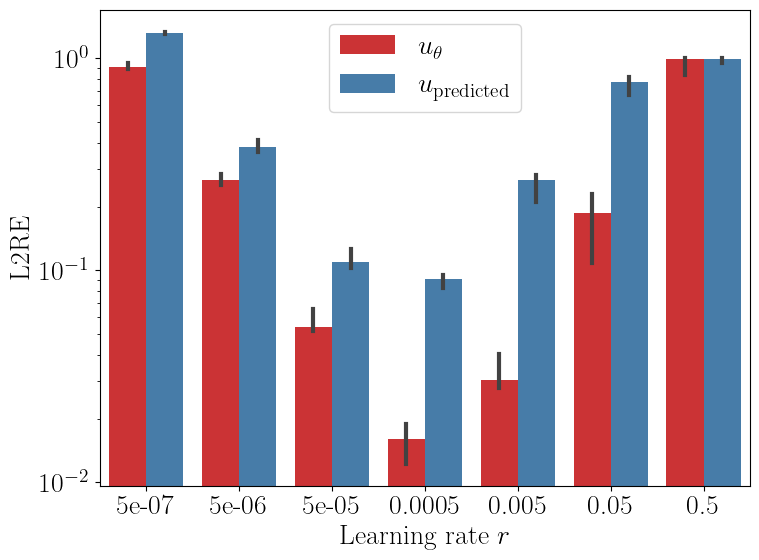

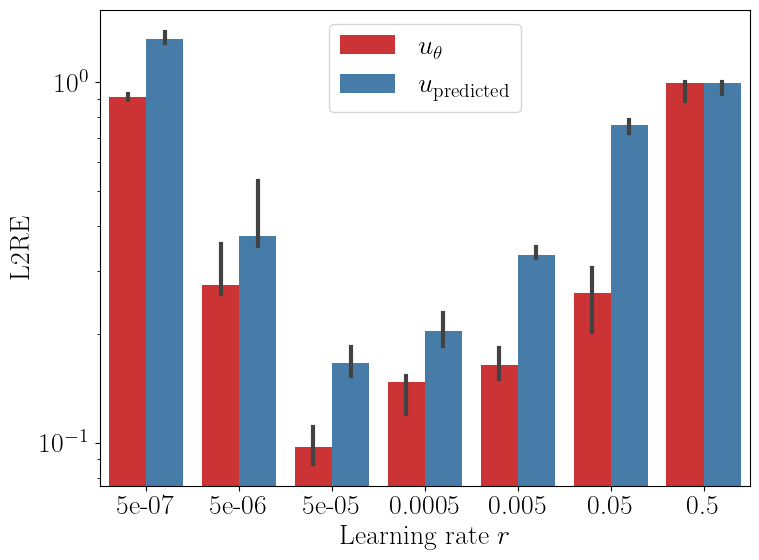

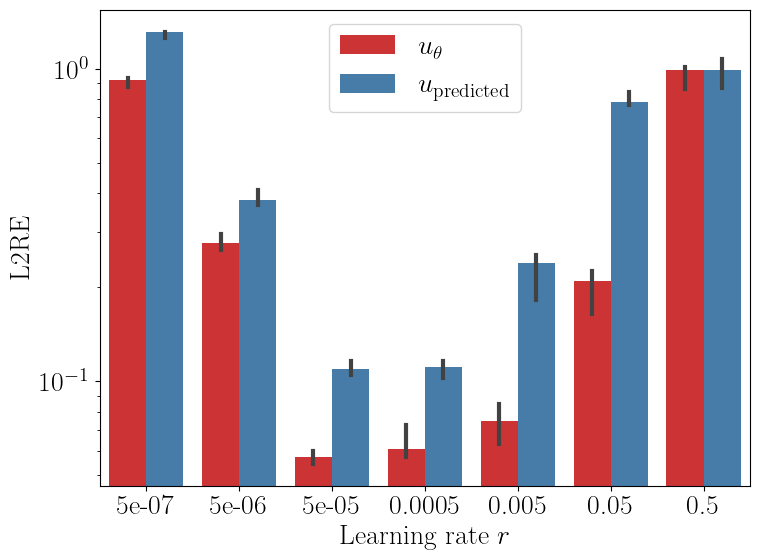

In [5]:
for var, subfolder in zip(variances, subfolders):

    save_dir = top_save_folder + f'var{var}/'

    errorS_uNN = np.load(save_dir + 'errorS_uNN.npy')
    errorS_uNN = errorS_uNN.reshape(len(learning_rates), NumRep)
    errorS_u_reconstr = np.load(save_dir + 'errorS_u_reconstr.npy')
    
    data = []
    for lr_ind in range(len(learning_rates)):
        lr = learning_rates[lr_ind]
        for rep in range(NumRep):
            data.append([lr, errorS_uNN[lr_ind][rep], r'$u_{\theta}$'])
            data.append([lr, errorS_u_reconstr[lr_ind][rep], r'$u_{\mathrm{predicted}}$'])
    df = pd.DataFrame(data, columns=[r'Learning rate $r$', 'L2RE', 'Quantity'])

    fig1, ax1 = plt.subplots(figsize=(8, 6))

    sns.barplot(
        x=r'Learning rate $r$',
        y='L2RE',
        hue='Quantity',
        data=df,
        ax=ax1,
        palette=colors,
        estimator=np.median,  # Set bar height to the median
        errorbar=('pi', 50)   # Set error bars to 50% prediction interval (25th to 75th percentile)
    )

    ax1.set_yscale('log')
    legend = ax1.get_legend()
    legend.set_title('')
    fig1.tight_layout()

    fig1.savefig(save_dir + f'L2RE_uNN_u_reconstr_var{var}.svg', format='svg', bbox_inches='tight')
    


### Plot: u_NN and u_reconstr for all variances for lr = 5e-2

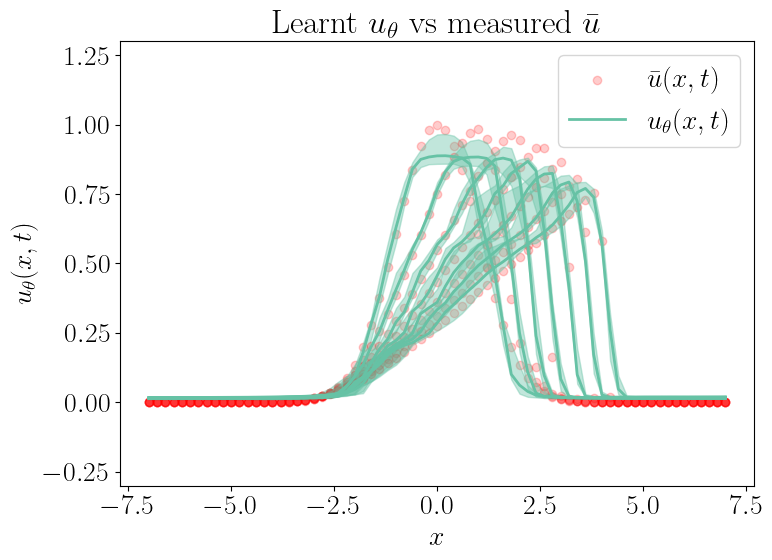

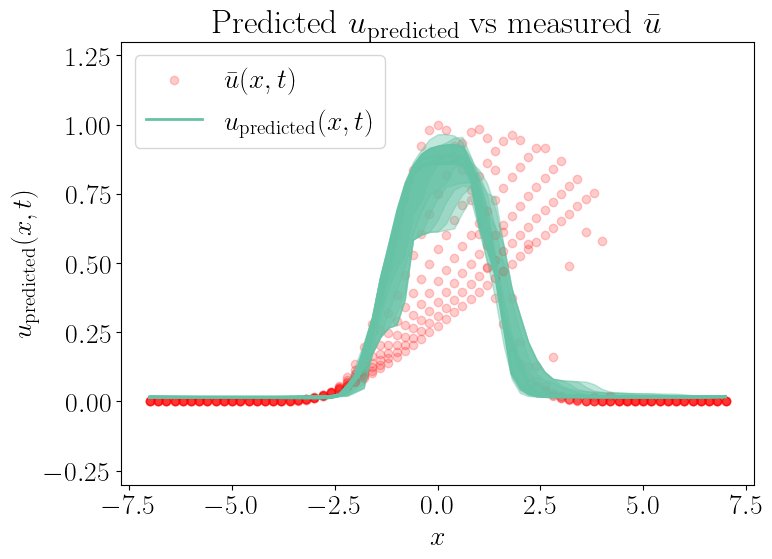

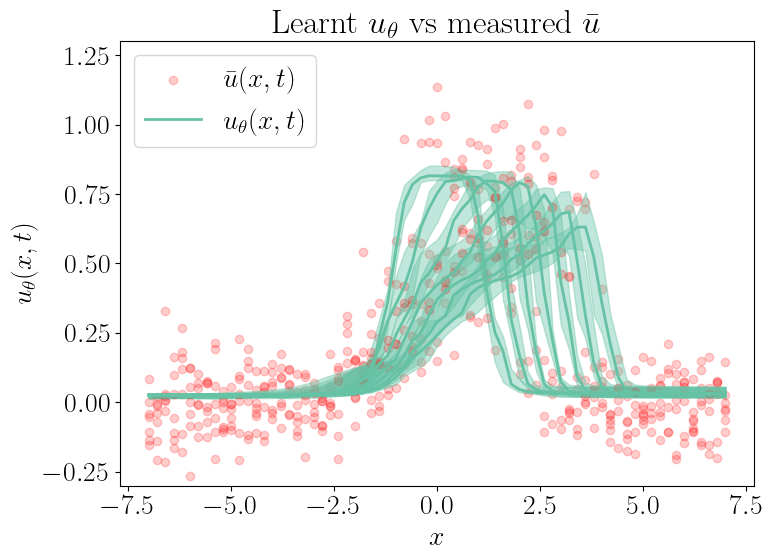

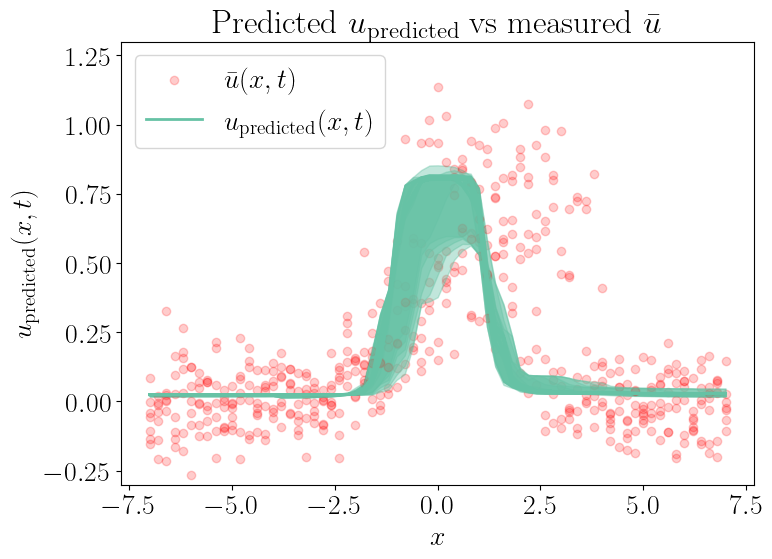

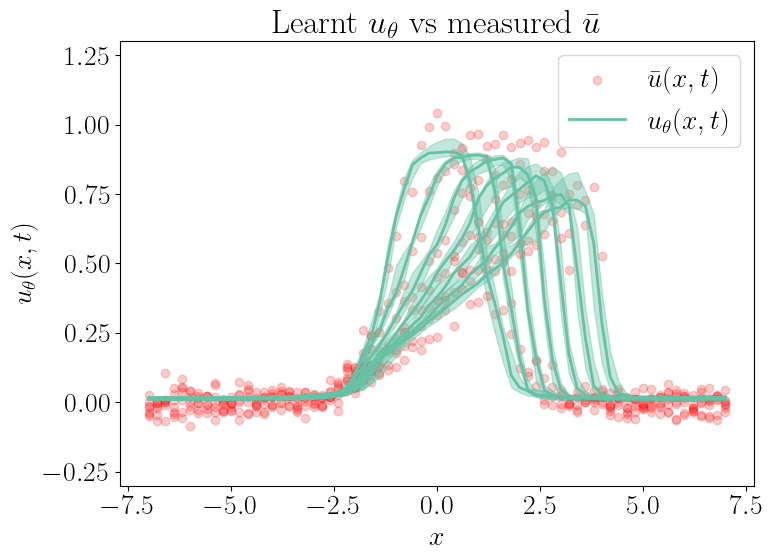

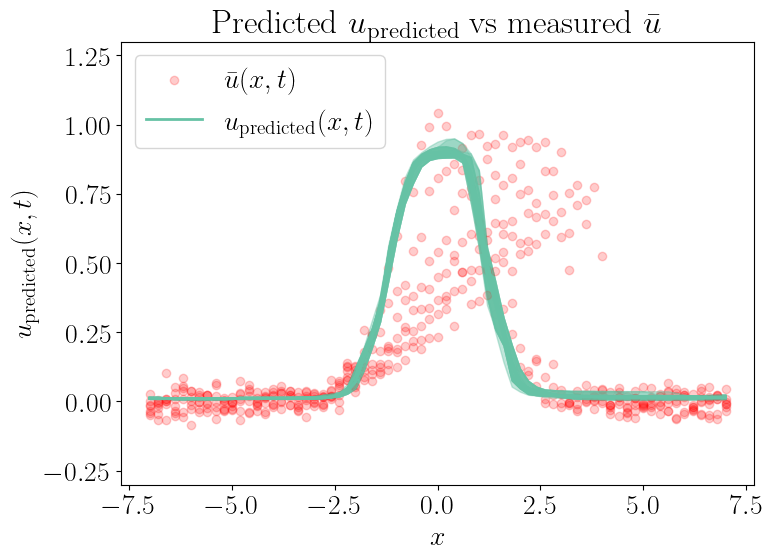

In [6]:
lr_ind1, lr_ind, lr = 0, 1, 5e-2
color = colors1[lr_ind1]

for var, subfolder in zip(variances, subfolders):

    noise_level = np.sqrt(var)
    np.random.seed(seed)
    additive_noise = noise_level * np.random.randn(*u_true.shape)
    u_true_noisy_IC = u_true + additive_noise

    save_dir = top_save_folder + f'var{var}/'
    load_dir = top_load_folder + subfolder

    u_reconstr_all = np.load(save_dir + 'u_reconstr_all.npy')

    # extract for lr_ind
    u_reconstr_all = u_reconstr_all[lr_ind, :, :, :] 

    u_NN_all = []
    for rep in range(NumRep):
        test_u_pred_np = np.load(load_dir + f'{lr}/Iter{rep}/fullgrid_u_pred.npy')
        u_NN_all.append(test_u_pred_np)
            
    u_NN_median, u_NN_25, u_NN_75 = np.median(np.array(u_NN_all), axis=0), np.percentile(np.array(u_NN_all), 25, axis=0), np.percentile(np.array(u_NN_all), 75, axis=0)
    u_reconstr_median, u_reconstr_25, u_reconstr_75 = np.median(np.array(u_reconstr_all), axis=0), np.percentile(np.array(u_reconstr_all), 25, axis=0), np.percentile(np.array(u_reconstr_all), 75, axis=0)

    # Plot u_NN:
    fig1, ax1 = plt.subplots(1, 1, figsize=(8, 6))
    for t in range(Nt):
        ax1.scatter(x_train, u_true_noisy_IC[t, :], color='red', alpha=0.2, label=r'$\bar{u}(x, t)$' if t == 0 else "")
        ax1.plot(x_train, u_NN_median[t, :], color=colors1[lr_ind1], label=r'$u_{\theta}(x, t)$' if t == 0 else "")
        ax1.fill_between(x_train, u_NN_25[t, :], u_NN_75[t, :], color=colors1[lr_ind1], alpha=alpha_val)
    ax1.set_title(r'Learnt $u_{\theta}$ vs measured $\bar{u}$')
    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$u_{\theta}(x, t)$')
    ax1.legend()
    ax1.set_ylim(-0.3, 1.3)
    fig1.tight_layout()
    fig1.savefig(save_dir + f'uNN_var{var}.svg', format='svg', bbox_inches='tight')

    # Plot u_reconstr:
    fig2, ax2 = plt.subplots(1, 1, figsize=(8, 6))
    for t in range(Nt):
        ax2.scatter(x_train, u_true_noisy_IC[t, :], color='red', alpha=0.2, label=r'$\bar{u}(x, t)$' if t == 0 else "")
        ax2.plot(x_train, u_reconstr_median[t, :], color=colors1[lr_ind1], label=r'$u_{\mathrm{predicted}}(x, t)$' if t == 0 else "")
        ax2.fill_between(x_train, u_reconstr_25[t, :], u_reconstr_75[t, :], color=colors1[lr_ind1], alpha=alpha_val)
    ax2.set_title(r'Predicted $u_{\mathrm{predicted}}$ vs measured $\bar{u}$')
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$u_{\mathrm{predicted}}(x, t)$')
    ax2.legend()
    ax2.set_ylim(-0.3, 1.3)
    fig2.tight_layout()
    fig2.savefig(save_dir + f'u_reconstr_var{var}.svg', format='svg', bbox_inches='tight')


### Plot D_NN and V_NN

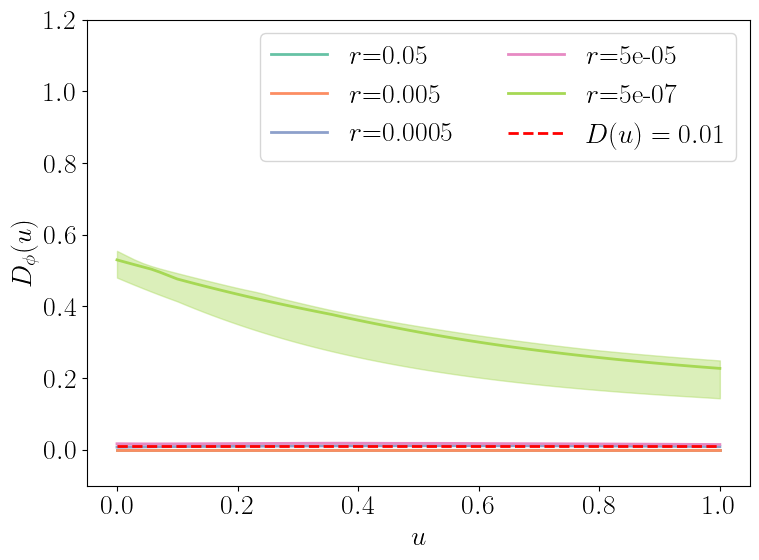

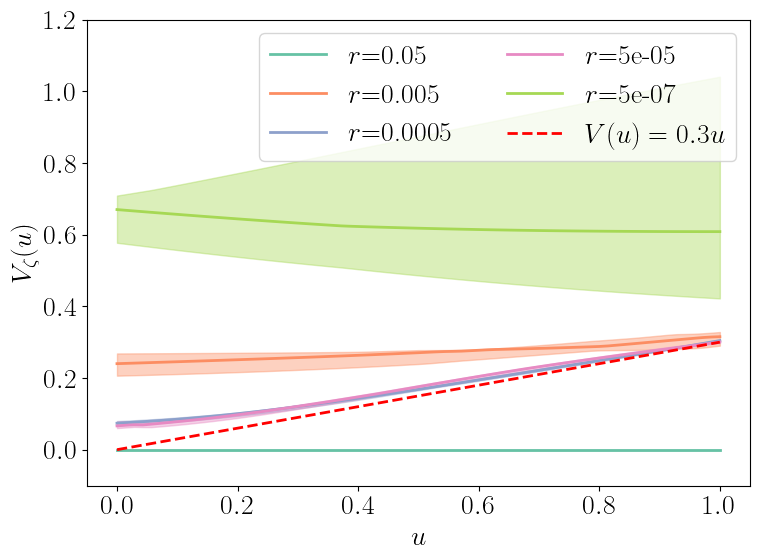

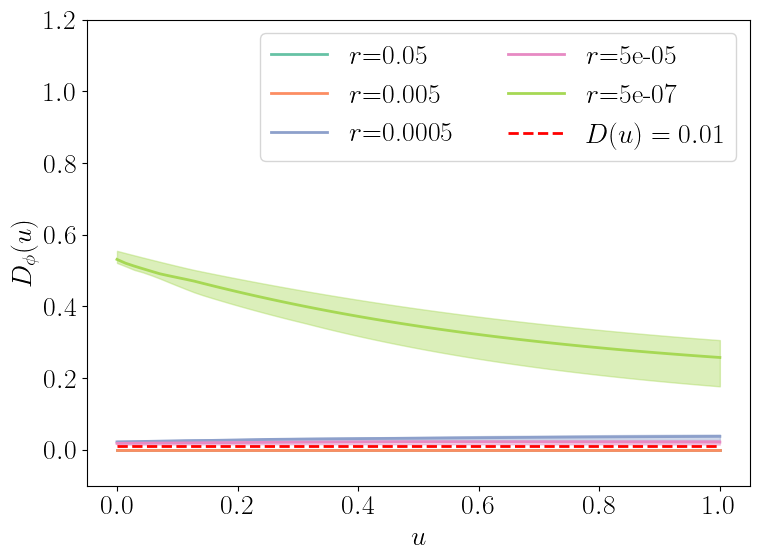

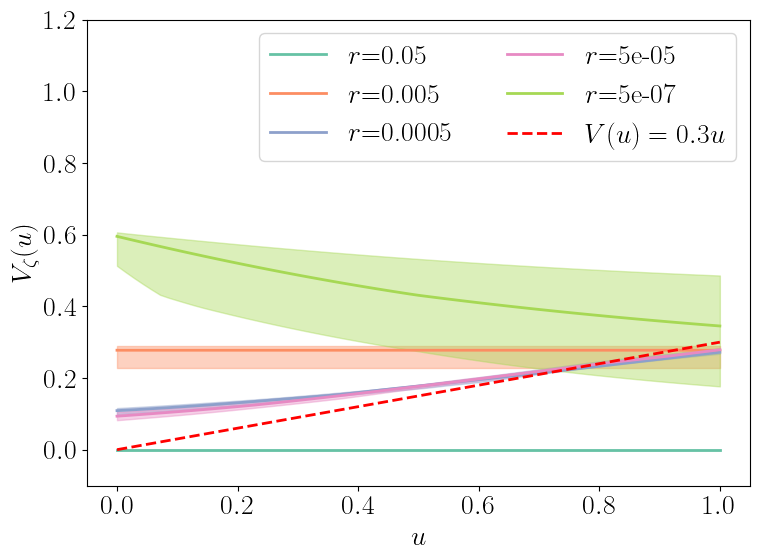

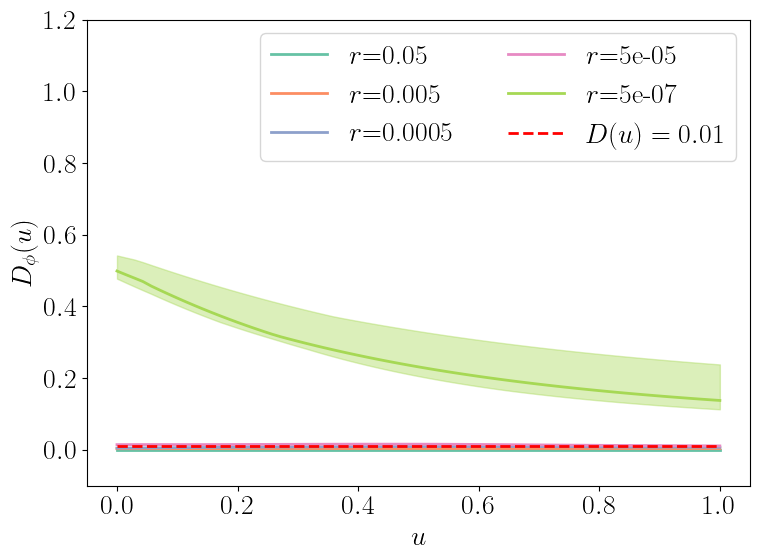

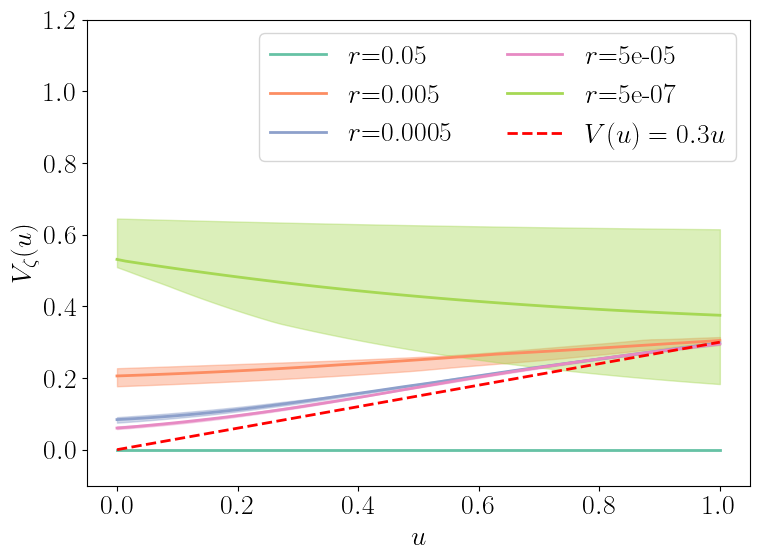

In [7]:
for var, subfolder in zip(variances, subfolders):

    save_dir = top_save_folder + f'var{var}/'
    load_dir = top_load_folder + subfolder

    fig1, ax1 = plt.subplots(1, 1, figsize=(8, 6))
    fig2, ax2 = plt.subplots(1, 1, figsize=(8, 6))

    for i, lr in enumerate(learning_rates1):
        D_reps = np.load(load_dir + f'{lr}/D_predS.npy')
        V_reps = np.load(load_dir + f'{lr}/V_predS.npy')
        D_median = np.median(D_reps, axis=0)
        D_q1 = np.percentile(D_reps, 25, axis=0)
        D_q3 = np.percentile(D_reps, 75, axis=0)
        V_median = np.median(V_reps, axis=0)
        V_q1 = np.percentile(V_reps, 25, axis=0)
        V_q3 = np.percentile(V_reps, 75, axis=0)

        # Plot D_NN:
        ax1.plot(U_grid, D_median, label=rf'$r$={lr}', color=colors1[i])
        ax1.fill_between(U_grid, D_q1, D_q3, color=colors1[i], alpha=alpha_val)

        # Plot V_NN:
        ax2.plot(U_grid, V_median, label=rf'$r$={lr}', color=colors1[i])
        ax2.fill_between(U_grid, V_q1, V_q3, color=colors1[i], alpha=alpha_val)

    ax1.plot(U_grid, D_true, label='$D(u)=0.01$', color='red', linestyle='--')
    ax2.plot(U_grid, V_true, label='$V(u)=0.3u$', color='red', linestyle='--')

    ax1.set_xlabel(r'$u$')
    ax1.set_ylabel(r'$D_{{\phi}}(u)$')
    ax1.legend(loc='upper right', ncol=2)
    ax1.set_ylim([-0.1, 1.2]) 


    ax2.set_xlabel(r'$u$')
    ax2.set_ylabel(r'$V_{{\zeta}}(u)$')
    ax2.legend(loc='upper right', ncol=2)
    ax2.set_ylim([-0.1, 1.2]) 

    fig1.tight_layout()
    fig2.tight_layout()
    fig1.savefig(save_dir + f'D_uNN_var{var}.svg', format='svg', bbox_inches='tight')
    fig2.savefig(save_dir + f'V_uNN_var{var}.svg', format='svg', bbox_inches='tight')

